# Scenario analysis / 场景分析

Baseline inputs are documented. Conservative and High-Density inputs are newly reconstructed examples, not recovered original inputs. / 基准输入有明确原始依据；保守与高密度输入为新增重建示例，不是找回的原始输入。

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

# Support execution from the repository or notebooks directory.
# 支持从仓库根目录或 notebooks 目录执行。
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Start in the repository / 请从仓库目录启动")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [2]:
from src.scenarios import evaluate_scenarios, compare_references
results = evaluate_scenarios(ROOT / "data/scenario_parameters.csv")
display(results[["scenario", "input_status", "servers_per_rack", "network_power_kw", "racks_per_pod", "pue", "notes_zh"]])
display(results[["scenario", "pod_facility_power_mw", "max_pods", "total_racks", "total_gpus", "remaining_capacity_mw"]])

,scenario,input_status,servers_per_rack,network_power_kw,racks_per_pod,pue,notes_zh
0,Conservative,reconstructed_assumption,3,1.2,24,1.25,新增示例假设：3台服务器、1.2 kW外部网络、24机架。与原始舍入结果相容；并非找回的原始输入。
1,Baseline,original_baseline,4,1.5,32,1.20,用于可复现容量计算的基准配置。
2,High-Density,reconstructed_assumption,5,2.0,32,1.15,新增示例假设：5台服务器、2.0 kW外部网络、32机架。仅评估功率；5台DGX B200机...


,scenario,pod_facility_power_mw,max_pods,total_racks,total_gpus,remaining_capacity_mw
0,Conservative,1.32300,377,9048,217152,1.22900
1,Baseline,2.25408,221,7072,226304,1.84832
2,High-Density,2.70480,184,5888,235520,2.31680


## Compare original display values / 核对原始显示值

Agreement is checked at source precision. It does not prove that reconstructed inputs were the original inputs. / 按原始精度核对，相符不等于证明重建输入就是原输入。

In [3]:
comparison = compare_references(results, ROOT / "data/original_scenario_references.csv")
display(comparison)
print("All displayed values match / 所有显示值一致:", bool(comparison.matches_display_precision.all()))

,scenario,input_status,metric,calculated,reference,matches_display_precision
0,Conservative,reconstructed_assumption,rack_it_power_kw,44.10000,44.10,True
1,Conservative,reconstructed_assumption,pod_it_power_mw,1.05840,1.06,True
2,Conservative,reconstructed_assumption,pue,1.25000,1.25,True
3,Conservative,reconstructed_assumption,pod_facility_power_mw,1.32300,1.32,True
4,Conservative,reconstructed_assumption,max_pods,377.00000,377.00,True
5,Baseline,original_baseline,rack_it_power_kw,58.70000,58.70,True
6,Baseline,original_baseline,pod_it_power_mw,1.87840,1.88,True
7,Baseline,original_baseline,pue,1.20000,1.20,True
8,Baseline,original_baseline,pod_facility_power_mw,2.25408,2.25,True
9,Baseline,original_baseline,max_pods,221.00000,221.00,True


All displayed values match / 所有显示值一致: True


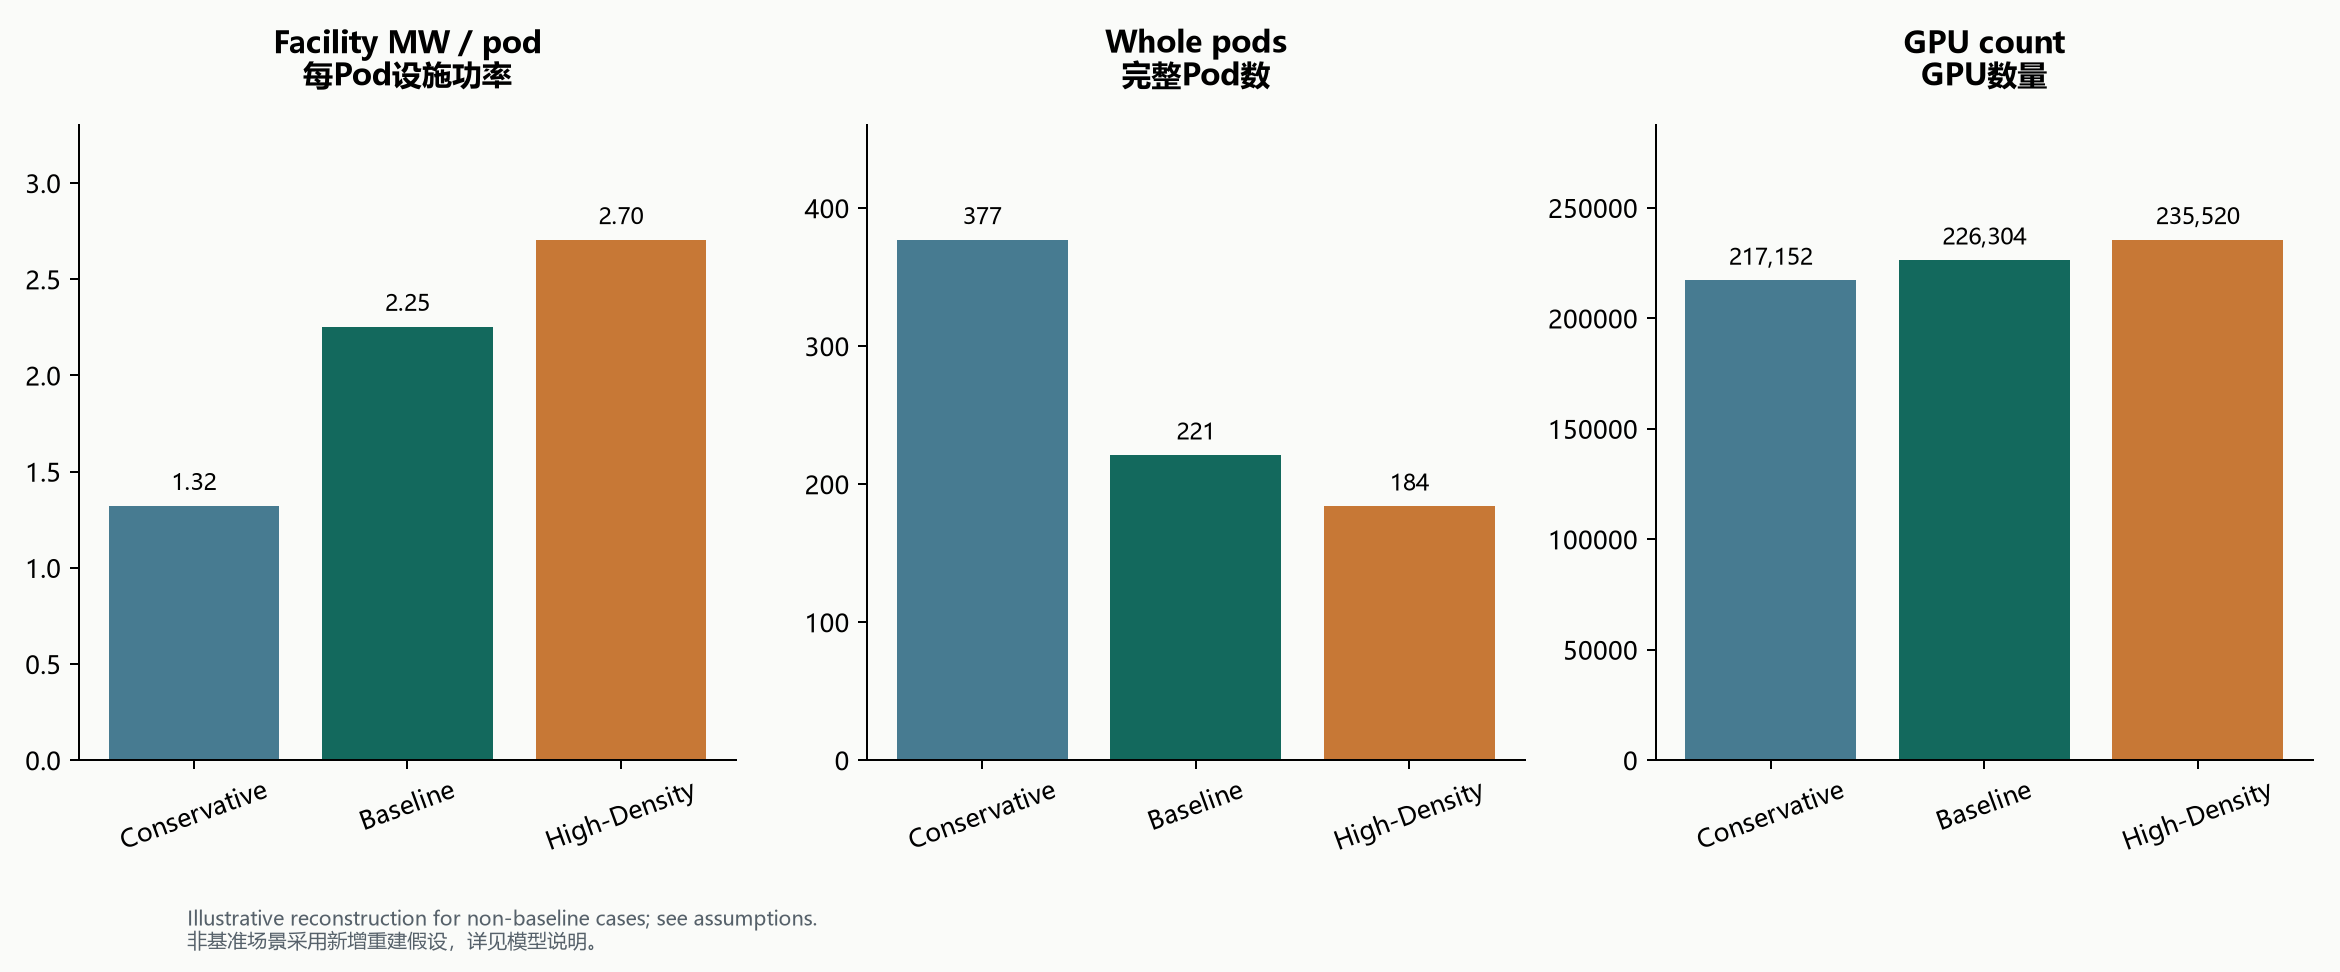

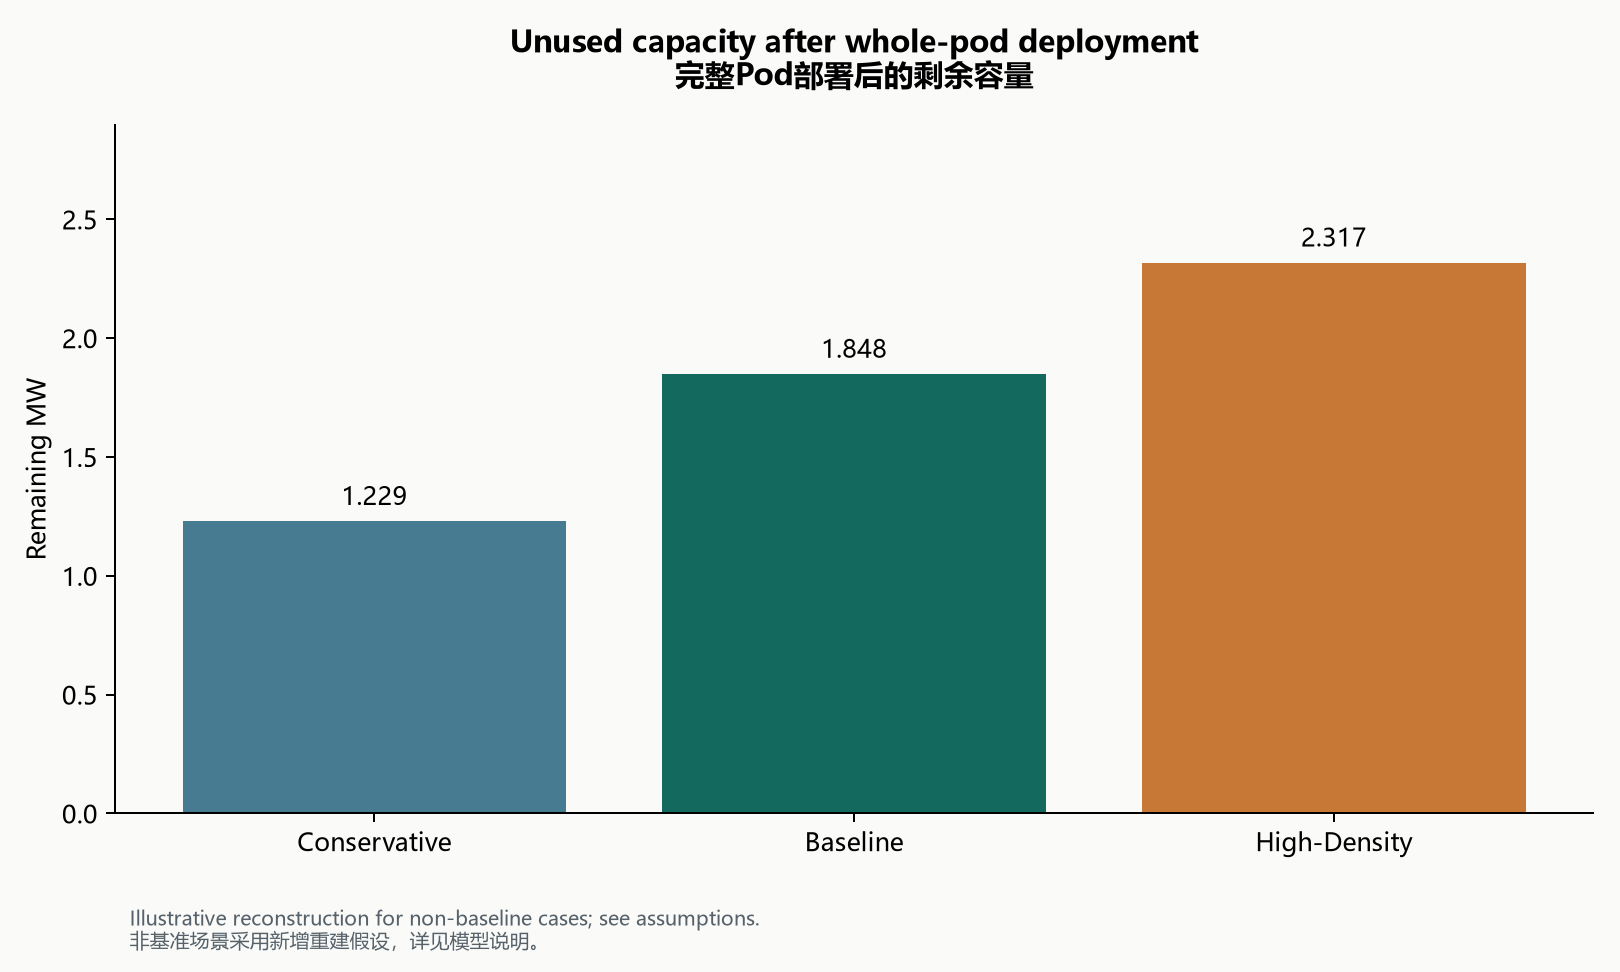

In [4]:
display(Image(filename=str(ROOT / "figures/scenario_comparison.png")))
display(Image(filename=str(ROOT / "figures/remaining_capacity.png")))

## Engineering observations / 工程观察

Conservative fits more pods but fewer GPUs than Baseline under the illustrated assumptions. High-Density fits fewer pods but more GPUs; PUE, density, network power and pod size differ between scenarios, so this is not a controlled density experiment. / 在示例假设下，保守场景Pod更多但GPU少于基准；高密度场景Pod更少而GPU更多。PUE、密度、网络功率与Pod大小同时存在差异，因此这不是单独控制密度的实验。

Five 10U chassis need 50U before networking. The High-Density case has no verified physical rack layout. / 五台10U机箱本身需要50U，尚未计入网络；高密度场景没有经过验证的物理机架布局。